In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os

from model import MaskGITTransformer
from utils import cosine_schedule, mask_by_confidence



In [2]:
OUTPUT_DIR = os.environ.get("OUTPUT_DIR", "checkpoints")
MASK_ID    = 8    # vocab_size
SEQ_LEN    = 784
IMG_SIZE   = 28


@torch.no_grad()
def generate(model, batch_size=16, T=20, temperature=1.0, seed=40):
    torch.manual_seed(seed)
    device = next(model.parameters()).device
    tokens = torch.full((batch_size, SEQ_LEN), MASK_ID,
                        dtype=torch.long, device=device)
    history = [tokens.clone()]

    for t in range(1, T + 1):
        logits     = model(tokens)[:, :, :MASK_ID] / temperature
        probs      = F.softmax(logits, dim=-1)
        sampled    = torch.multinomial(
            probs.view(-1, MASK_ID), 1
        ).view(batch_size, SEQ_LEN)
        confidence = probs.gather(-1, sampled.unsqueeze(-1)).squeeze(-1)

        currently_masked = (tokens == MASK_ID)
        tokens      = torch.where(currently_masked, sampled, tokens)
        confidence  = torch.where(
            currently_masked, confidence, torch.ones_like(confidence)
        )
        n_to_mask   = cosine_schedule(t, T, SEQ_LEN)
        new_mask    = mask_by_confidence(confidence, n_to_mask)
        tokens[new_mask] = MASK_ID
        history.append(tokens.clone())

    return tokens, history


def tokens_to_image(tokens):
    """Convert (784,) token tensor → (28,28) float image in [0,1]."""
    # Replace any remaining MASK_IDs with 0 (background)
    t = tokens.clone()
    t[t == MASK_ID] = 0
    return t.reshape(IMG_SIZE, IMG_SIZE).float() / (MASK_ID - 1)


# ── Load model ────────────────────────────────────────────────────────────────
ckpt  = torch.load(os.path.join(OUTPUT_DIR, "maskgit_mnist.pt"), map_location="cpu")
model = MaskGITTransformer(
    vocab_size = ckpt["vocab_size"],
    seq_len    = ckpt["seq_len"],
    d_model    = ckpt["d_model"],
    n_heads    = ckpt["n_heads"],
    n_layers   = ckpt["n_layers"],
    d_ff       = ckpt["d_ff"],
)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Model loaded — vocab={ckpt['vocab_size']}, seq_len={ckpt['seq_len']}")


Model loaded — vocab=8, seq_len=784


/raven/ptmp/fatel/MaskedGIT/model.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [3]:
sequences, _ = generate(model, batch_size=16, T=12)

for i in range(16):
    print(i, torch.sum(sequences[i]))

0 tensor(302)
1 tensor(327)
2 tensor(338)
3 tensor(318)
4 tensor(281)
5 tensor(321)
6 tensor(315)
7 tensor(322)
8 tensor(307)
9 tensor(345)
10 tensor(296)
11 tensor(309)
12 tensor(334)
13 tensor(328)
14 tensor(323)
15 tensor(338)


In [25]:
print(sequences[0].reshape(28,28))

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 7, 4, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 7, 6, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 7, 6, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 7, 4, 5, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 7, 6, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 7, 6, 0, 0, 0, 0, 0, 0

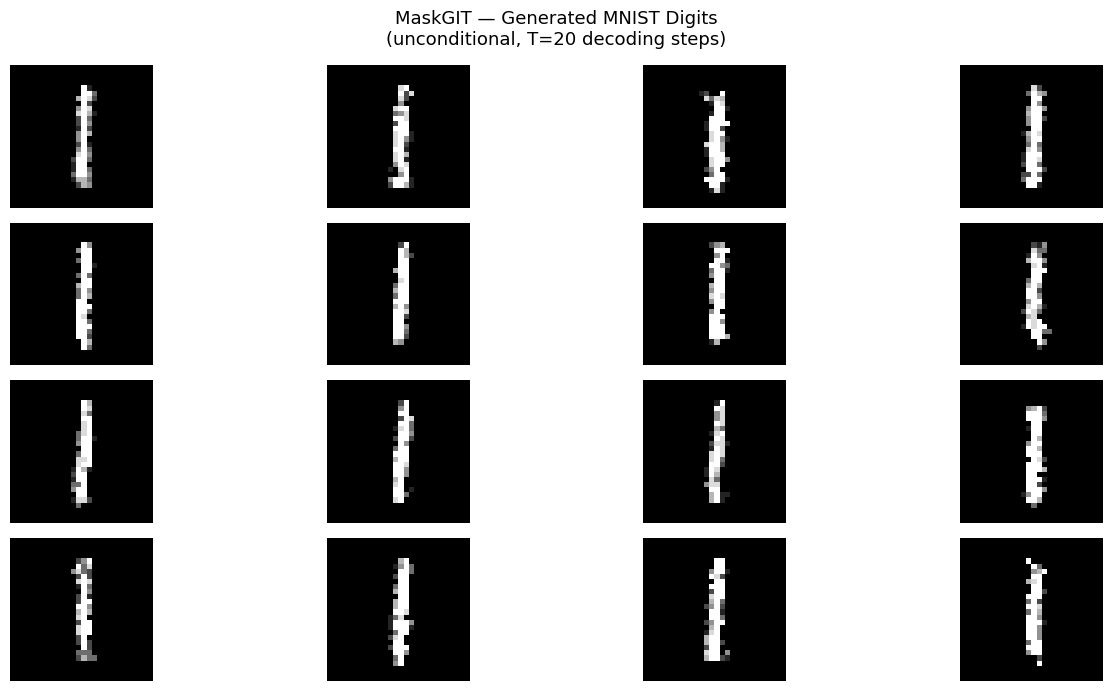

In [29]:
# Figure 1: Generated samples
#print("Generating digits...")
sequences, history = generate(model, batch_size=16, T=20, temperature=2)

fig, axes = plt.subplots(4, 4, figsize=(14, 7))
fig.suptitle(
    "MaskGIT — Generated MNIST Digits\n"
    "(unconditional, T=20 decoding steps)",
    fontsize=13
)

for i, ax in enumerate(axes.flat):
    img = tokens_to_image(sequences[i]).numpy()
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

plt.tight_layout()
plt.show()

Visualising iterative decoding...


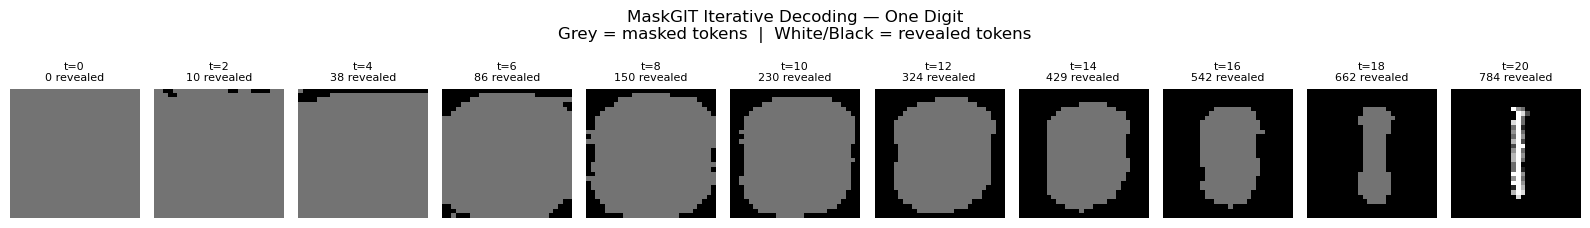

In [26]:

print("Visualising iterative decoding...")
sequences_single, history_single = generate(
    model, batch_size=1, T=20, temperature=1.0, seed=7
)

# Pick 10 evenly spaced steps to show
steps_to_show = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(16, 2.5))
fig.suptitle("MaskGIT Iterative Decoding — One Digit\n"
             "Grey = masked tokens  |  White/Black = revealed tokens",
             fontsize=12)

for ax, t in zip(axes, steps_to_show):
    state = history_single[t][0]   # (784,)

    # Build display image:
    # masked positions → mid-grey (0.5)
    # revealed positions → actual token value
    img = torch.zeros(SEQ_LEN)
    mask = (state == MASK_ID)
    img[~mask] = state[~mask].float() / (MASK_ID - 1)
    img[mask]  = 0.45   # mid-grey for masked

    n_masked = mask.sum().item()
    ax.imshow(img.reshape(IMG_SIZE, IMG_SIZE).numpy(),
              cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"t={t}\n{SEQ_LEN-n_masked} revealed", fontsize=8)
    ax.axis("off")

plt.tight_layout()

plt.show()



In [13]:
with torch.no_grad():
    tokens = torch.full((1, SEQ_LEN), MASK_ID, device=next(model.parameters()).device)
    logits = model(tokens)[:, :, :MASK_ID]

pred = logits.argmax(-1)[0]
print(torch.bincount(pred, minlength=MASK_ID))

tensor([770,   0,   0,   0,   0,   0,   0,  14])


In [31]:
import torch

flat = torch.stack([sequences[i] for i in range(8)])
print("pairwise equality:", torch.all(flat[0] == flat[1:]))
print("token std:", flat.float().std())

pairwise equality: tensor(False)
token std: tensor(1.5596)


Temperature sweep...


KeyboardInterrupt: 

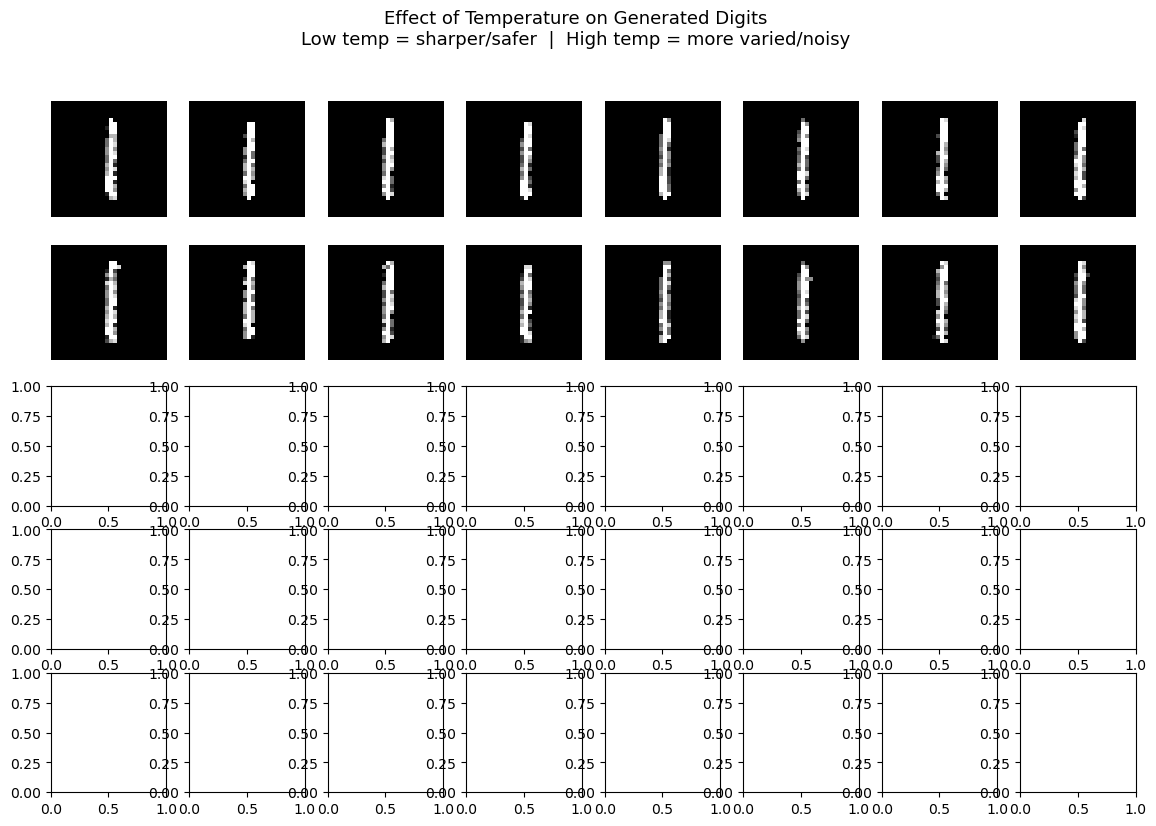

In [5]:


# ── Figure 3: Temperature sweep ───────────────────────────────────────────────
print("Temperature sweep...")
temps = [0.5, 0.8, 1.0, 1.2, 1.5]
fig, axes = plt.subplots(len(temps), 8, figsize=(14, 9))
fig.suptitle("Effect of Temperature on Generated Digits\n"
             "Low temp = sharper/safer  |  High temp = more varied/noisy",
             fontsize=13)

for row, temp in enumerate(temps):
    seqs, _ = generate(model, batch_size=8, T=20, temperature=temp, seed=0)
    for col in range(8):
        img = tokens_to_image(seqs[col]).numpy()
        axes[row, col].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"T={temp}", fontsize=11, rotation=0,
                             labelpad=35, va="center")

plt.tight_layout()
plt.savefig("mnist_temperature.png", dpi=150)
plt.show()
print("Saved mnist_temperature.png")


# ── Figure 4: Inpainting ──────────────────────────────────────────────────────
# Give the model the top half of real digits, let it complete the bottom
# This is exactly the inpainting task from the paper (Section 4.3)
print("Inpainting...")
from mnist_data import MNISTTokenDataset
test_ds = MNISTTokenDataset(train=False, n_bins=8)

n_examples = 8
fig, axes  = plt.subplots(3, n_examples, figsize=(14, 5.5))
fig.suptitle("MaskGIT Inpainting — Top Half Given, Bottom Half Generated\n"
             "(Paper Section 4.3 equivalent)", fontsize=12)

for i in range(n_examples):
    original = test_ds[i].unsqueeze(0)   # (1, 784)

    # Mask the bottom half (rows 14-27 → positions 392-783)
    masked          = original.clone()
    masked[0, 392:] = MASK_ID

    # Run generation starting from this partial image
    tokens  = masked.clone()
    for t in range(1, 21):
        with torch.no_grad():
            logits     = model(tokens)[:, :, :MASK_ID] / 0.8
            probs      = F.softmax(logits, dim=-1)
            sampled    = torch.multinomial(
                probs.view(-1, MASK_ID), 1
            ).view(1, SEQ_LEN)
            confidence = probs.gather(-1, sampled.unsqueeze(-1)).squeeze(-1)

        currently_masked = (tokens == MASK_ID)
        tokens      = torch.where(currently_masked, sampled, tokens)
        confidence  = torch.where(
            currently_masked, confidence, torch.ones_like(confidence)
        )
        # Only re-mask positions that were originally masked
        n_to_mask = cosine_schedule(t, 20, 392)   # schedule over 392 tokens
        if n_to_mask > 0:
            # Only consider originally-masked positions for re-masking
            conf_bottom        = confidence.clone()
            conf_bottom[0, :392] = 1.0   # never re-mask the top half
            new_mask           = mask_by_confidence(conf_bottom, n_to_mask)
            tokens[new_mask]   = MASK_ID

    # Plot original | masked input | inpainted result
    axes[0, i].imshow(tokens_to_image(original[0]).numpy(),
                      cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(tokens_to_image(masked[0]).numpy(),
                      cmap="gray", vmin=0, vmax=1)
    axes[2, i].imshow(tokens_to_image(tokens[0]).numpy(),
                      cmap="gray", vmin=0, vmax=1)
    for row in range(3):
        axes[row, i].axis("off")

axes[0, 0].set_ylabel("Original",  fontsize=10, rotation=0, labelpad=45, va="center")
axes[1, 0].set_ylabel("Top half\ngiven",   fontsize=10, rotation=0, labelpad=45, va="center")
axes[2, 0].set_ylabel("Inpainted", fontsize=10, rotation=0, labelpad=45, va="center")

plt.tight_layout()
plt.savefig("mnist_inpainting.png", dpi=150)
plt.show()
print("Saved mnist_inpainting.png")

print("\nAll done. Generated figures:")
print("  mnist_generated.png      — 32 generated digits")
print("  mnist_decoding_steps.png — iterative decoding visualised")
print("  mnist_temperature.png    — temperature effect")
print("  mnist_inpainting.png     — bottom half completion")

Ink pixel count distribution:
  min: 49, max: 60, mean: 54.8


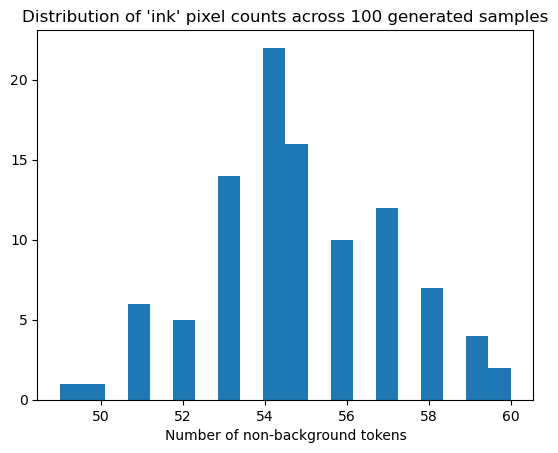

In [6]:
import torch
import torch.nn.functional as F
from collections import Counter

# Generate 100 sequences, classify by simple heuristic: count "ink" pixels
sequences, _ = generate(model, batch_size=100, T=20, temperature=1.0, seed=123)

ink_counts = (sequences != 0).sum(dim=1)  # how many non-background tokens per image
print("Ink pixel count distribution:")
print(f"  min: {ink_counts.min().item()}, max: {ink_counts.max().item()}, mean: {ink_counts.float().mean().item():.1f}")

# "1" digits typically have very few ink pixels (thin vertical line)
# "8" digits typically have many ink pixels (dense loops)
import matplotlib.pyplot as plt
plt.hist(ink_counts.numpy(), bins=20)
plt.xlabel("Number of non-background tokens")
plt.title("Distribution of 'ink' pixel counts across 100 generated samples")
plt.savefig("ink_distribution.png")
plt.show()

Summary: 
min:49, max:60 confirms it: every single generated image has almost the same number of ink pixels. That's definitive mode collapse, not just visual similarity. The model found one "safe" answer and always produces it.
How We've Handled MNIST So Far
Tokenization approach: raw pixel quantization
MNIST image (28×28, pixel values in [0,1])
        ↓
Flatten to 784-length sequence
        ↓
Quantize each pixel into one of 8 grey-level bins:
    token = floor(pixel_value × 8), clamped to [0, 7]
        ↓
Result: sequence of 784 tokens, vocab_size = 8
This was implemented in mnist_data.py's MNISTTokenDataset — pixels themselves became tokens, no learned tokenizer involved. Each token directly corresponds to one pixel's brightness level.
Why this worked but had a ceiling:

Simple, fast, no extra training needed
But 784 independent low-information decisions gave the model many chances to find a "safe default" (mostly background), leading to mode collapse — generation converged to producing only "1"-like digits regardless of input
We diagnosed this concretely: ink-pixel count across 100 generated samples was 49–60, essentially constant — confirming the model learned one dominant mode rather than the full data distribution

The rest of the pipeline (model, masking, training, decoding) needed zero changes — only data.py changed when we moved from synthetic tasks to MNIST. That modularity is exactly why switching to VQVAE tokens will also be a clean swap.

# Trying my VQVAE on MNIST

In [22]:
import torch
from collections import Counter

data = torch.load("mnist_vqvae_tokens_train.pt")
tokens = data["tokens"]   # (60000, 49)

flat = tokens.flatten().tolist()
counts = Counter(flat)
most_common = counts.most_common(10)

print("Top 10 most frequent codes in REAL training data:")
for code, count in most_common:
    pct = 100 * count / len(flat)
    print(f"  code {code:>3}: {count:>7} times ({pct:.1f}%)")

print(f"\nTotal unique codes used: {len(counts)}/128")

Top 10 most frequent codes in REAL training data:
  code 102: 1296922 times (44.1%)
  code 106:  357319 times (12.2%)
  code  40:  181219 times (6.2%)
  code  83:   65370 times (2.2%)
  code  44:   62995 times (2.1%)
  code   9:   47306 times (1.6%)
  code  35:   43836 times (1.5%)
  code 108:   38493 times (1.3%)
  code   6:   34742 times (1.2%)
  code  10:   29190 times (1.0%)

Total unique codes used: 75/128


In [3]:
import torch
import torch.nn.functional as F
from model import MaskGITTransformer
import os

ckpt = torch.load(os.path.join(os.environ.get("OUTPUT_DIR","checkpoints"), "maskgit_vqvae_mnist.pt"), map_location="cpu")
model = MaskGITTransformer(
    vocab_size=ckpt["vocab_size"], seq_len=ckpt["seq_len"],
    d_model=ckpt["d_model"], n_heads=ckpt["n_heads"],
    n_layers=ckpt["n_layers"], d_ff=ckpt["d_ff"],
)
model.load_state_dict(ckpt["model_state"])
model.eval()

MASK_ID = 128

# Step 1: what does model predict from fully masked input?
tokens = torch.full((1, 49), MASK_ID, dtype=torch.long)
with torch.no_grad():
    logits = model(tokens)[:, :, :MASK_ID]   # (1, 49, 128)
    probs  = F.softmax(logits, dim=-1)        # (1, 49, 128)

# Most likely token at each position
top_tokens = probs[0].argmax(dim=-1)
print("Most likely token at each position (fully masked input):")
print(top_tokens.tolist())
print(f"Unique predicted tokens: {top_tokens.unique().tolist()}")

# Top-5 tokens at position 0
top5_probs, top5_idx = probs[0, 0].topk(5)
print(f"\nTop 5 tokens at position 0:")
for idx, p in zip(top5_idx.tolist(), top5_probs.tolist()):
    print(f"  token {idx:>3}: prob {p:.4f}")

# How concentrated is the distribution?
entropy = -(probs[0] * (probs[0] + 1e-10).log()).sum(dim=-1)
print(f"\nPer-position entropy (max={torch.log(torch.tensor(128.)):.2f}):")
print(f"  mean: {entropy.mean():.3f}")
print(f"  min:  {entropy.min():.3f}")
print(f"  max:  {entropy.max():.3f}")

/raven/ptmp/fatel/MaskedGIT/model.py:77: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Most likely token at each position (fully masked input):
[102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 72, 106, 102, 102, 102, 102, 106, 40, 9, 102, 102, 102, 102, 106, 9, 9, 102, 102, 102, 102, 40, 9, 106, 102, 102, 102, 102, 40, 9, 106, 102, 102, 102, 102, 102, 102, 102, 102, 102]
Unique predicted tokens: [9, 40, 72, 102, 106]

Top 5 tokens at position 0:
  token 102: prob 0.9982
  token 106: prob 0.0016
  token  83: prob 0.0001
  token  44: prob 0.0000
  token 108: prob 0.0000

Per-position entropy (max=4.85):
  mean: 2.031
  min:  0.014
  max:  3.933


Total tokens    : 2,940,000
Unique codes    : 75/128

Code usage distribution:
  code      count      pct  bar
-------------------------------------------------------
   102  1,296,922   44.11%  ████████████████████████████████████████████████████████████████████████████████████████
   106    357,319   12.15%  ████████████████████████
    40    181,219    6.16%  ████████████
    83     65,370    2.22%  ████
    44     62,995    2.14%  ████
     9     47,306    1.61%  ███
    35     43,836    1.49%  ██
   108     38,493    1.31%  ██
     6     34,742    1.18%  ██
    10     29,190    0.99%  █
   105     28,761    0.98%  █
    88     27,372    0.93%  █
     1     26,652    0.91%  █
    30     26,609    0.91%  █
   127     25,508    0.87%  █
    48     24,213    0.82%  █
   113     23,604    0.80%  █
   115     22,496    0.77%  █
    98     22,277    0.76%  █
    66     21,153    0.72%  █
    72     20,664    0.70%  █
    76     19,986    0.68%  █
    82     19,273    0.66%  █
    65     

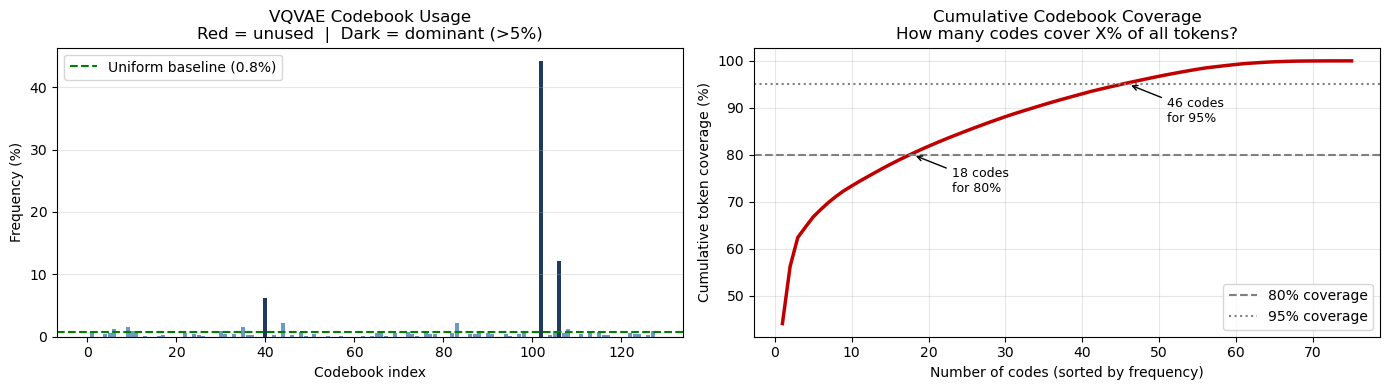


Summary:
  Codes covering 50% of tokens : 2
  Codes covering 80% of tokens : 18
  Codes covering 95% of tokens : 46
  Unused codes                 : 53
  Top-1 code frequency         : 44.1%
  Uniform baseline             : 0.8%


In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

data   = torch.load("mnist_vqvae_tokens_train.pt")
tokens = data["tokens"].flatten().tolist()   # all 60000*49 = 2,940,000 tokens
counts = Counter(tokens)

# ── 1. Print full distribution ─────────────────────────────────────────────
print(f"Total tokens    : {len(tokens):,}")
print(f"Unique codes    : {len(counts)}/128")
print(f"\nCode usage distribution:")
print(f"{'code':>6}  {'count':>9}  {'pct':>7}  {'bar'}")
print("-" * 55)
for code, count in sorted(counts.items(), key=lambda x: -x[1]):
    pct = 100 * count / len(tokens)
    bar = "█" * int(pct / 0.5)   # one block per 0.5%
    print(f"  {code:>4}  {count:>9,}  {pct:>6.2f}%  {bar}")

# ── 2. Visualise ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: bar chart of all code frequencies
all_codes   = list(range(128))
all_counts  = [counts.get(c, 0) for c in all_codes]
colors      = ["#C00000" if counts.get(c, 0) == 0 else
               "#1E3A5F" if counts.get(c, 0) / len(tokens) > 0.05 else
               "#6B9AC4" for c in all_codes]

axes[0].bar(all_codes, [counts.get(c, 0) / len(tokens) * 100 for c in all_codes],
            color=colors, width=0.9)
axes[0].set_xlabel("Codebook index")
axes[0].set_ylabel("Frequency (%)")
axes[0].set_title("VQVAE Codebook Usage\n"
                  "Red = unused  |  Dark = dominant (>5%)")
axes[0].axhline(100/128, color="green", linestyle="--",
                label=f"Uniform baseline ({100/128:.1f}%)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Right: cumulative distribution — how many codes cover X% of tokens?
sorted_counts = sorted(counts.values(), reverse=True)
cumulative    = np.cumsum(sorted_counts) / len(tokens) * 100
axes[1].plot(range(1, len(cumulative)+1), cumulative,
             color="#C00000", linewidth=2.5)
axes[1].axhline(80, color="gray", linestyle="--", label="80% coverage")
axes[1].axhline(95, color="gray", linestyle=":",  label="95% coverage")
axes[1].set_xlabel("Number of codes (sorted by frequency)")
axes[1].set_ylabel("Cumulative token coverage (%)")
axes[1].set_title("Cumulative Codebook Coverage\n"
                  "How many codes cover X% of all tokens?")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Annotate: how many codes for 80% and 95%
for threshold in [80, 95]:
    n_codes = next(i+1 for i, c in enumerate(cumulative) if c >= threshold)
    axes[1].annotate(f"{n_codes} codes\nfor {threshold}%",
                     xy=(n_codes, threshold),
                     xytext=(n_codes + 5, threshold - 8),
                     fontsize=9, color="black",
                     arrowprops=dict(arrowstyle="->", color="black"))

plt.tight_layout()
plt.savefig("codebook_usage.png", dpi=150)
plt.show()

# ── 3. Summary statistics ──────────────────────────────────────────────────
print(f"\nSummary:")
print(f"  Codes covering 50% of tokens : "
      f"{next(i+1 for i,c in enumerate(cumulative) if c>=50)}")
print(f"  Codes covering 80% of tokens : "
      f"{next(i+1 for i,c in enumerate(cumulative) if c>=80)}")
print(f"  Codes covering 95% of tokens : "
      f"{next(i+1 for i,c in enumerate(cumulative) if c>=95)}")
print(f"  Unused codes                 : {128 - len(counts)}")
print(f"  Top-1 code frequency         : "
      f"{max(counts.values())/len(tokens)*100:.1f}%")
print(f"  Uniform baseline             : {100/128:.1f}%")

In [10]:
!pwd

/raven/ptmp/fatel/MaskedGIT/mnist


In [9]:
os.chdir("/raven/ptmp/fatel/MaskedGIT/mnist")

Unique codes used : 128/128
Top-1 frequency   : 6.0%  (was 44.1%)
Uniform baseline  : 0.8%

Top 10 most common:
  code 116:   6.0%  ████████████
  code  49:   6.0%  ████████████
  code  53:   5.4%  ██████████
  code 102:   4.8%  █████████
  code  17:   3.0%  ██████
  code 115:   2.3%  ████
  code  85:   1.8%  ███
  code  27:   1.3%  ██
  code 110:   1.2%  ██
  code 121:   1.0%  ██


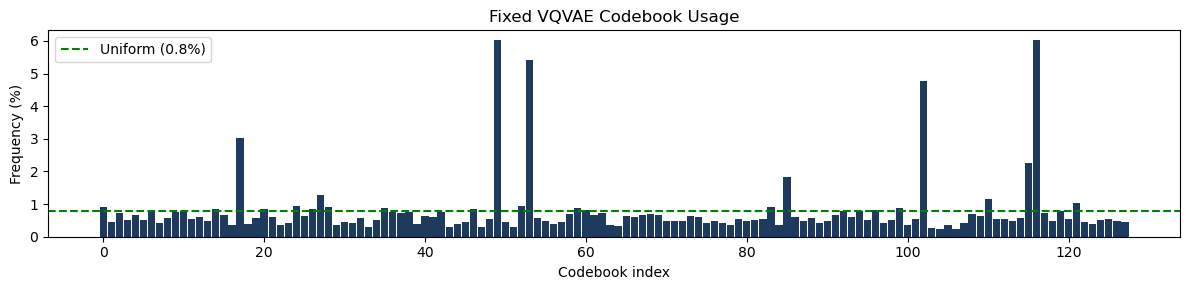

In [12]:
# new VQVAE
# quick_check.py — just load the saved tokens and check distribution
import torch
from collections import Counter
import matplotlib.pyplot as plt

data   = torch.load("mnist_vqvae_tokens_train.pt")
tokens = data["tokens"].flatten().tolist()
counts = Counter(tokens)

print(f"Unique codes used : {len(counts)}/128")
print(f"Top-1 frequency   : {max(counts.values())/len(tokens)*100:.1f}%  (was 44.1%)")
print(f"Uniform baseline  : {100/128:.1f}%")
print(f"\nTop 10 most common:")
for code, count in counts.most_common(10):
    pct = 100 * count / len(tokens)
    bar = "█" * int(pct / 0.5)
    print(f"  code {code:>3}: {pct:>5.1f}%  {bar}")

# Plot
plt.figure(figsize=(12, 3))
freqs  = [counts.get(c, 0) / len(tokens) * 100 for c in range(128)]
colors = ["#C00000" if counts.get(c, 0) == 0 else "#1E3A5F" for c in range(128)]
plt.bar(range(128), freqs, color=colors, width=0.9)
plt.axhline(100/128, color="green", linestyle="--", label=f"Uniform ({100/128:.1f}%)")
plt.xlabel("Codebook index")
plt.ylabel("Frequency (%)")
plt.title("Fixed VQVAE Codebook Usage")
plt.legend()
plt.tight_layout()
plt.savefig("codebook_fixed.png", dpi=150)
plt.show()

# Nice, fixed the VQVAE
Fix 1: Exponential Moving Average (EMA) updates for codebook
       → more stable than gradient updates, standard in VQVAE literature

Fix 2: Dead code restart
       → any code unused for a while gets reset to a random encoder output
       → breaks the positive feedback loop

Fix 3: Encoder output normalization
       → normalize z before quantization so all codes compete fairly

In [7]:
import sys
import os

# Replace with the path to the folder containing your modules
module_path = os.path.abspath("//viper/u2/fatel/HEP4M/MaskedGIT/mnist/") 
if module_path not in sys.path:
    sys.path.append(module_path)


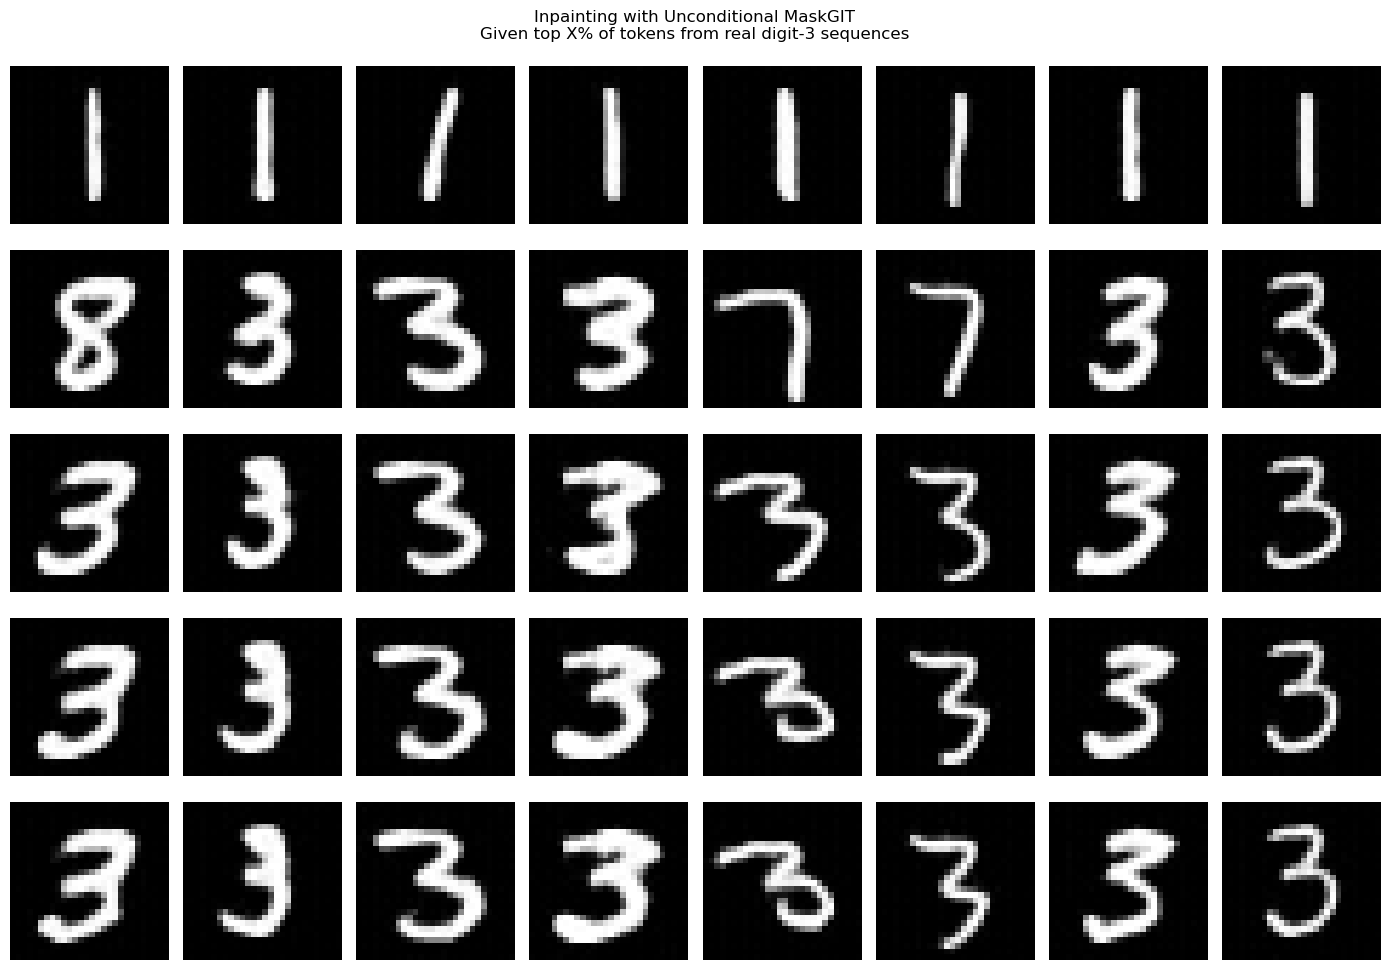

In [18]:
# inpainting, giving the unconditional model some known tokens (all from the digit 3) and letting it fill in the rest
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from model import MaskGITTransformer
from utils import cosine_schedule, mask_by_confidence
from VQVAE import VQVAE

BASE_DIR   = os.environ.get("BASE_DIR", "/viper/u2/fatel/HEP4M/MaskedGIT/mnist")
OUTPUT_DIR = os.environ.get("OUTPUT_DIR", os.path.join(BASE_DIR, "checkpoints"))

VOCAB_SIZE = 128
SEQ_LEN    = 49
GRID_SIZE  = 7
MASK_ID    = VOCAB_SIZE


def decode_tokens(vqvae, tokens):
    B = tokens.shape[0]
    with torch.no_grad():
        codes  = tokens.view(B, GRID_SIZE, GRID_SIZE)
        z_q    = vqvae.vq.embedding[codes]
        z_q    = z_q.permute(0, 3, 1, 2).contiguous()
        images = vqvae.decoder(z_q).clamp(0, 1)
    return images


@torch.no_grad()
def inpaint(model, tokens, known_mask, T=20, temperature=1.0):
    """
    Inpainting — some tokens are given (known_mask=True),
    the rest are masked and generated by the model.

    Args:
        tokens     : (B, L) — real token sequences (full, from dataset)
        known_mask : (B, L) bool — True = this position is GIVEN, keep it
                     False = this position is masked, model must generate it
    """
    B = tokens.shape[0]

    # Start: mask all unknown positions
    current = tokens.clone()
    current[~known_mask] = MASK_ID

    for t in range(1, T + 1):
        logits     = model(current)[:, :, :MASK_ID] / temperature
        probs      = F.softmax(logits, dim=-1)
        sampled    = torch.multinomial(
            probs.view(-1, MASK_ID), 1
        ).view(B, SEQ_LEN)
        confidence = probs.gather(-1, sampled.unsqueeze(-1)).squeeze(-1)

        # Only update currently masked positions
        masked     = current == MASK_ID
        current    = torch.where(masked, sampled, current)
        confidence = torch.where(masked, confidence, torch.ones_like(confidence))

        # Re-mask least confident UNKNOWN positions only
        # Never re-mask the known (given) positions
        n_to_mask = cosine_schedule(t, T, SEQ_LEN)
        if n_to_mask > 0:
            # Set confidence of known positions to 1.0 so they never get re-masked
            conf_unknown = confidence.clone()
            conf_unknown[known_mask] = 1.0
            new_mask = mask_by_confidence(conf_unknown, n_to_mask)
            # Extra safety: never re-mask known positions
            new_mask[known_mask] = False
            current[new_mask] = MASK_ID

    return current


# ── Load models ───────────────────────────────────────────────────────────────
ckpt = torch.load("/viper/u2/fatel/HEP4M/MaskedGIT/checkpoints/maskgit_vqvae_fixed_mnist.pt", map_location="cpu")
model = MaskGITTransformer(
    vocab_size=ckpt["vocab_size"], seq_len=ckpt["seq_len"],
    d_model=ckpt["d_model"], n_heads=ckpt["n_heads"],
    n_layers=ckpt["n_layers"], d_ff=ckpt["d_ff"],
)
model.load_state_dict(ckpt["model_state"])
model.eval()

vqvae = VQVAE(num_embeddings=128, embedding_dim=64, in_channels=1)
vqvae.load_state_dict(
    torch.load(os.path.join(BASE_DIR, "vqvae_mnist.pt"), map_location="cpu")
)
vqvae.eval()

# ── Load real tokens ──────────────────────────────────────────────────────────
data   = torch.load(os.path.join(BASE_DIR, "mnist_vqvae_tokens_train.pt"))
tokens = data["tokens"]   # (60000, 49)
labels = data["labels"]   # (60000,)

# Get 8 real digit-3 sequences
digit3_idx = (labels == 3).nonzero().squeeze()[:8]
digit3_tokens = tokens[digit3_idx]   # (8, 49)

# ── Try different masking ratios ──────────────────────────────────────────────
# How much context do we need to give before the model generates correctly?
fig, axes = plt.subplots(5, 8, figsize=(14, 10))
fig.suptitle("Inpainting with Unconditional MaskGIT\n"
             "Given top X% of tokens from real digit-3 sequences",
             fontsize=12)

reveal_ratios = [0.0, 0.25, 0.50, 0.75, 1.0]
labels_text   = ["0% given\n(unconditional)", "25% given",
                 "50% given", "75% given", "100% given\n(original)"]

for row, (ratio, label_text) in enumerate(zip(reveal_ratios, labels_text)):
    if ratio == 0.0:
        # Pure unconditional — no context
        known_mask = torch.zeros(8, SEQ_LEN, dtype=torch.bool)
    elif ratio == 1.0:
        # Show original image — no generation needed
        result = digit3_tokens.clone()
        imgs   = decode_tokens(vqvae, result)
        for col in range(8):
            axes[row, col].imshow(imgs[col].squeeze().numpy(),
                                  cmap="gray", vmin=0, vmax=1)
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(label_text, fontsize=9, rotation=0,
                                 labelpad=55, va="center")
        continue
    else:
        # Give the model the top `ratio` fraction of tokens
        # (top rows of the 7×7 grid)
        n_known    = int(ratio * SEQ_LEN)
        known_mask = torch.zeros(8, SEQ_LEN, dtype=torch.bool)
        known_mask[:, :n_known] = True   # reveal first n_known positions

    result = inpaint(model, digit3_tokens, known_mask, T=20, temperature=1.0)
    imgs   = decode_tokens(vqvae, result)

    for col in range(8):
        axes[row, col].imshow(imgs[col].squeeze().numpy(),
                              cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(label_text, fontsize=9, rotation=0,
                             labelpad=55, va="center")

plt.tight_layout()
#plt.savefig(os.path.join(BASE_DIR, "inpainting_digit3.png"), dpi=150)
plt.show()
#print("Saved inpainting_digit3.png")

# Conditional Model

In [13]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from cmodel import MaskGITTransformer
from utils import cosine_schedule, mask_by_confidence
from VQVAE import VQVAE

BASE_DIR   = os.environ.get("BASE_DIR",   "/viper/u2/fatel/HEP4M/MaskedGIT/mnist")
OUTPUT_DIR = os.environ.get("OUTPUT_DIR", os.path.join(BASE_DIR, "checkpoints"))

VOCAB_SIZE = 128
SEQ_LEN    = 49
GRID_SIZE  = 7
MASK_ID    = VOCAB_SIZE


@torch.no_grad()
def generate_tokens(model, labels, T=20, temperature=1.0,
                    cfg_weight=3.0):
    """
    Class-conditional generation with classifier-free guidance.

    CFG formula (from reference code):
        logit = (1 + w) * logit_conditional - w * logit_unconditional
    """
    batch_size  = len(labels)
    device      = next(model.parameters()).device
    labels      = torch.tensor(labels, dtype=torch.long, device=device)
    tokens      = torch.full((batch_size, SEQ_LEN), MASK_ID,
                             dtype=torch.long, device=device)
    null_labels = torch.full_like(labels, model.NULL_CLASS)
    no_drop     = torch.zeros(batch_size, dtype=torch.bool, device=device)

    for t in range(1, T + 1):
        if cfg_weight > 0:
            # Run model twice — once with label, once without
            logit_c = model(tokens, labels,      no_drop)[:, :, :MASK_ID]
            logit_u = model(tokens, null_labels, no_drop)[:, :, :MASK_ID]
            logits  = (1 + cfg_weight) * logit_c - cfg_weight * logit_u
        else:
            logits = model(tokens, labels, no_drop)[:, :, :MASK_ID]

        logits     = logits / temperature
        probs      = F.softmax(logits, dim=-1)
        sampled    = torch.multinomial(
            probs.view(-1, MASK_ID), 1
        ).view(batch_size, SEQ_LEN)
        confidence = probs.gather(-1, sampled.unsqueeze(-1)).squeeze(-1)

        masked     = tokens == MASK_ID
        tokens     = torch.where(masked, sampled, tokens)
        confidence = torch.where(masked, confidence, torch.ones_like(confidence))

        n_to_mask = cosine_schedule(t, T, SEQ_LEN)
        new_mask  = mask_by_confidence(confidence, n_to_mask)
        tokens[new_mask] = MASK_ID

    return tokens


def decode_tokens(vqvae, tokens):
    """Token sequences → pixel images via VQVAE decoder."""
    B = tokens.shape[0]
    with torch.no_grad():
        codes  = tokens.view(B, GRID_SIZE, GRID_SIZE)
        z_q    = vqvae.vq.embedding[codes]              # (B, 7, 7, emb_dim)
        z_q    = z_q.permute(0, 3, 1, 2).contiguous()  # (B, emb_dim, 7, 7)
        images = vqvae.decoder(z_q).clamp(0, 1)        # (B, 1, 28, 28)
    return images


# ── Load MaskGIT ──────────────────────────────────────────────────────────────
print("Loading MaskGIT...")
ckpt = torch.load("/viper/u2/fatel/HEP4M/MaskedGIT/checkpoints/maskgit_cond.pt", map_location="cpu")
maskgit = MaskGITTransformer(
    vocab_size = ckpt["vocab_size"],
    seq_len    = ckpt["seq_len"],
    n_classes  = ckpt["n_classes"],
    d_model    = ckpt["d_model"],
    n_heads    = ckpt["n_heads"],
    n_layers   = ckpt["n_layers"],
    d_ff       = ckpt["d_ff"],
)
maskgit.load_state_dict(ckpt["model_state"])
maskgit.eval()

# ── Load VQVAE ────────────────────────────────────────────────────────────────
print("Loading VQVAE...")
vqvae = VQVAE(num_embeddings=128, embedding_dim=64, in_channels=1)
vqvae.load_state_dict(
    torch.load(os.path.join(BASE_DIR, "vqvae_mnist.pt"), map_location="cpu")
)
vqvae.eval()

Loading MaskGIT...


//viper/u2/fatel/HEP4M/MaskedGIT/mnist/cmodel.py:70: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Loading VQVAE...


VQVAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): GroupNorm(8, 64, eps=1e-05, affine=True)
      (5): ReLU()
      (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): GroupNorm(8, 64, eps=1e-05, affine=True)
      (8): ReLU()
      (9): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (vq): VectorQuantizerEMA()
  (decoder): Decoder(
    (conv): Sequential(
      (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (2): ReLU()
      (3): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): GroupNorm(8, 64, eps=1e-05, affine=True)
      (5): ReLU()
      (6): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padd

Generating 4 samples per digit...


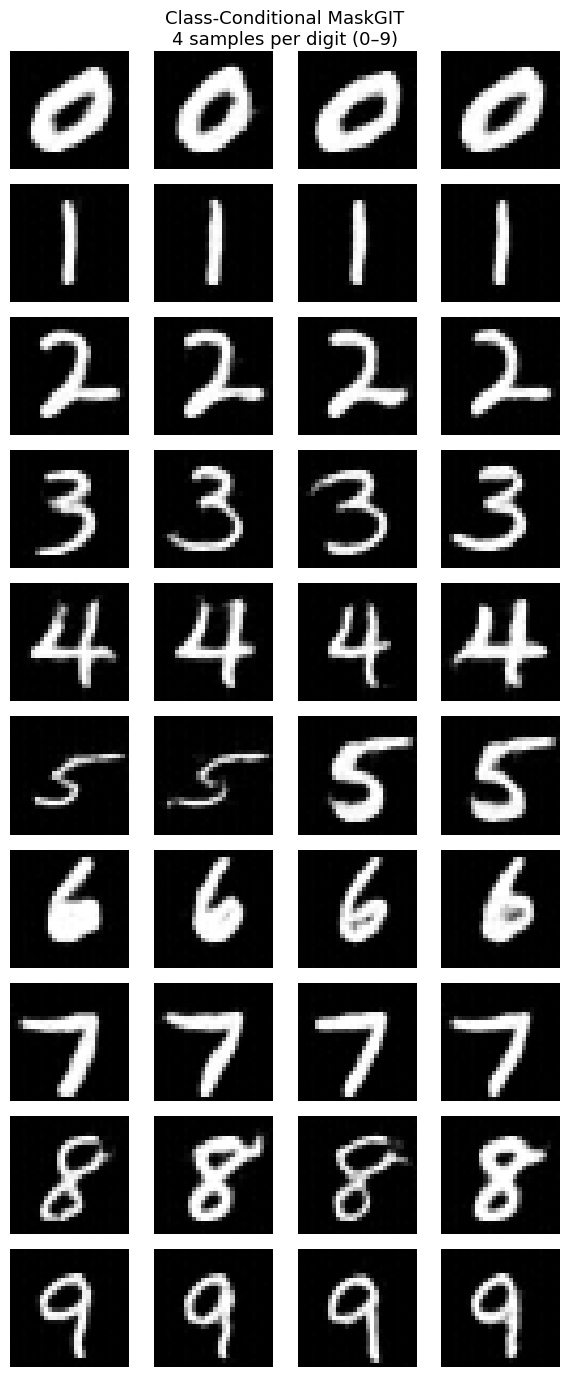

In [15]:
# ── Figure 1: 4 samples per digit, all 10 digits ─────────────────────────────
print("Generating 4 samples per digit...")
labels    = [d for d in range(10) for _ in range(4)]  # [0,0,0,0,1,1,1,1,...]
sequences = generate_tokens(maskgit, labels, T=20, temperature=1.0, cfg_weight=3.0)
images    = decode_tokens(vqvae, sequences)

fig, axes = plt.subplots(10, 4, figsize=(6, 14))
fig.suptitle("Class-Conditional MaskGIT\n4 samples per digit (0–9)", fontsize=13)
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
    if i % 4 == 0:
        ax.set_ylabel(str(labels[i]), fontsize=14, rotation=0,
                      labelpad=20, va="center")
plt.tight_layout()
#plt.savefig(os.path.join(BASE_DIR, "mnist_conditional.png"), dpi=150)
plt.show()
#print("Saved mnist_conditional.png")


Testing CFG weights...


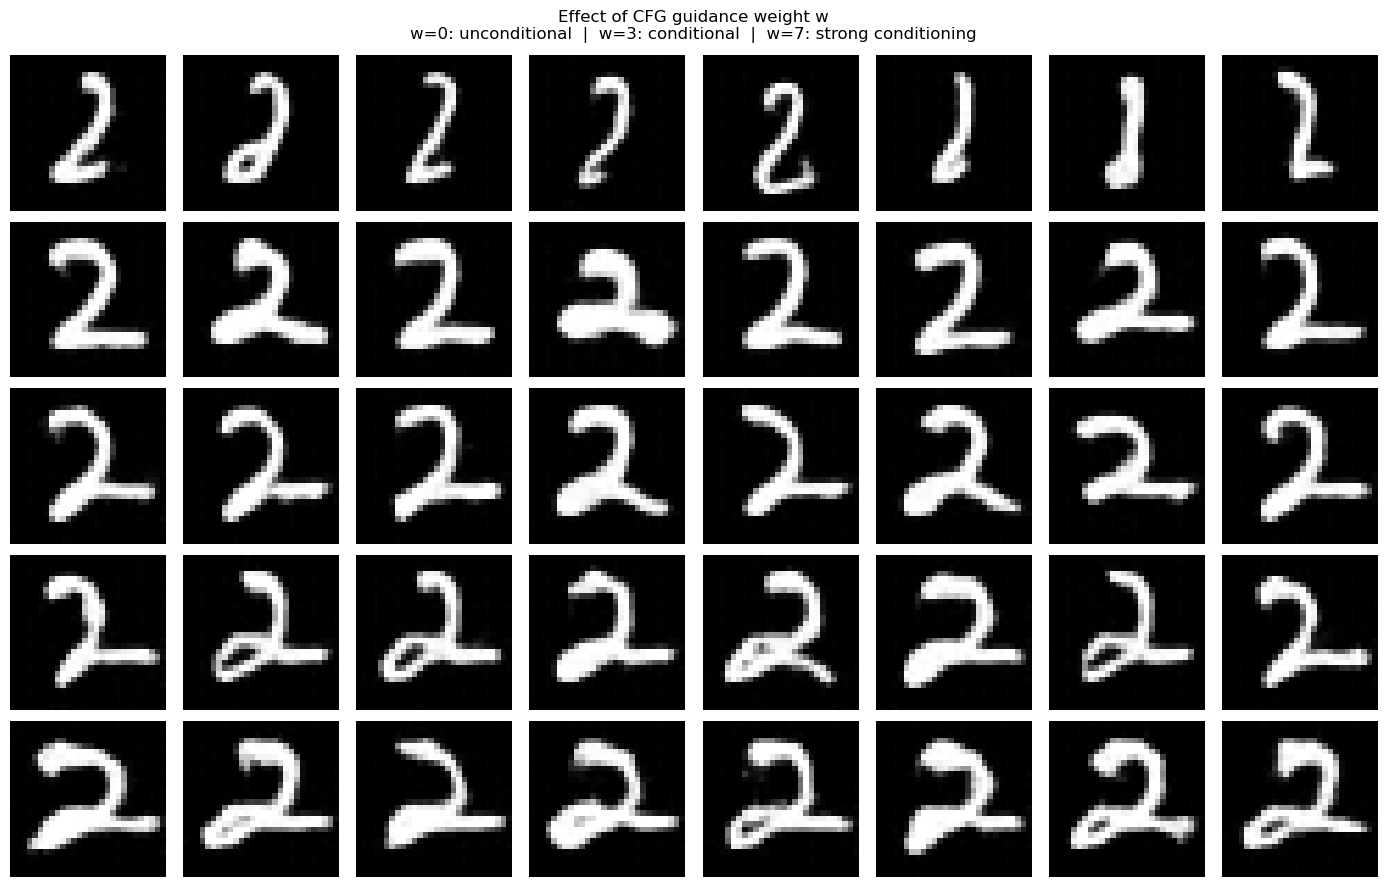

In [16]:
# ── Figure 2: Effect of CFG weight ───────────────────────────────────────────
print("Testing CFG weights...")
fig, axes = plt.subplots(5, 8, figsize=(14, 9))
fig.suptitle("Effect of CFG guidance weight w\n"
             "w=0: unconditional  |  w=3: conditional  |  w=7: strong conditioning",
             fontsize=12)

cfg_weights = [0, 1, 3, 5, 7]
for row, w in enumerate(cfg_weights):
    seqs = generate_tokens(maskgit, [2]*8, T=20, temperature=1.0, cfg_weight=w)
    imgs = decode_tokens(vqvae, seqs)
    for col in range(8):
        axes[row, col].imshow(imgs[col].squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"w={w}", fontsize=11, rotation=0,
                             labelpad=30, va="center")

plt.tight_layout()
#plt.savefig(os.path.join(BASE_DIR, "mnist_cfg_weight.png"), dpi=150)
plt.show()
#print("Saved mnist_cfg_weight.png")